# Assignment 7: Build and Evaluate Unsupervised Learning Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 1

For a cluster \(C_k\) with \(n_k\) observations and centroid \(\bar{x}_k\), the K-means within-cluster objective is
\[
\sum_{i \in C_k}\sum_{j=1}^{p}(x_{ij}-\bar{x}_{kj})^2.
\]
The pairwise form in ISLR can be proved by centering each observation around the cluster mean.  For one variable,
\[
\sum_{i \in C_k}\sum_{i' \in C_k}(x_i-x_{i'})^2
= \sum_{i}\sum_{i'}[(x_i-\bar{x})-(x_{i'}-\bar{x})]^2.
\]
Expanding the square gives
\[
n_k\sum_i(x_i-\bar{x})^2+n_k\sum_{i'}(x_{i'}-\bar{x})^2-2\left(\sum_i(x_i-\bar{x})\right)\left(\sum_{i'}(x_{i'}-\bar{x})\right).
\]
The last term is zero because deviations from the mean sum to zero, so the pairwise sum equals \(2n_k\sum_i(x_i-\bar{x})^2\).  Summing over all variables gives
\[
\frac{1}{2n_k}\sum_{i \in C_k}\sum_{i' \in C_k}\sum_{j=1}^{p}(x_{ij}-x_{i'j})^2
=
\sum_{i \in C_k}\sum_{j=1}^{p}(x_{ij}-\bar{x}_{kj})^2.
\]
That proves the pairwise-distance objective and the centroid-based within-cluster objective are the same objective written two ways.

Part (b) follows from the two steps of the algorithm.  The assignment step cannot increase the objective because each observation is assigned to the nearest current centroid.  The update step cannot increase the objective because the sample mean is the least-squares minimizer for the observations assigned to that cluster.  Therefore each full iteration weakly decreases the objective until the algorithm reaches a local optimum, although not necessarily the global optimum (MacQueen, 1967).

## Applied Question 9: USArrests Hierarchical Clustering

The USArrests exercise shows why scaling matters in unsupervised learning.  Without scaling, variables with larger units dominate Euclidean distance.  After scaling, each variable contributes on a comparable standard-deviation scale.

### Q9(a): Complete-Linkage Clustering Without Scaling

I first cluster the original USArrests variables using complete linkage and Euclidean distance.  This answers the first part of the exercise in the original measurement units, before correcting for scale effects.

,state_count
raw_cluster,
1,16
2,14
3,20


,cluster,state
rownames,,
Alabama,1,Alabama
Alaska,1,Alaska
Arizona,1,Arizona
California,1,California
Delaware,1,Delaware
Florida,1,Florida
Illinois,1,Illinois
Louisiana,1,Louisiana
Maryland,1,Maryland


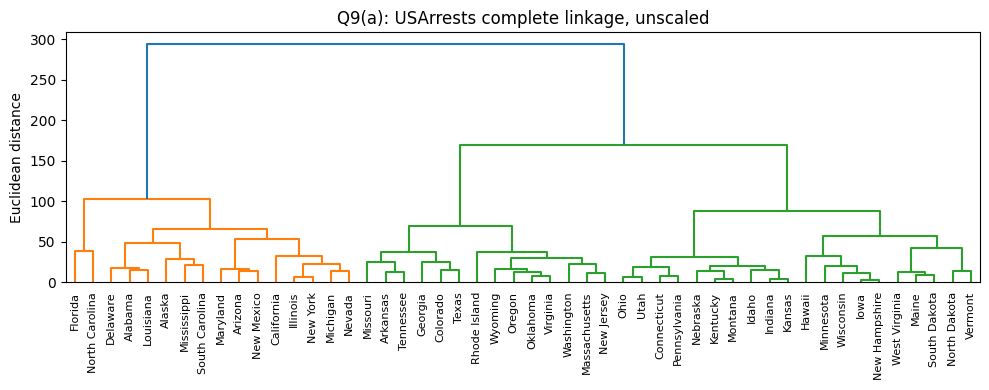

In [2]:
import statsmodels.api as sm
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.preprocessing import StandardScaler

usarrests = sm.datasets.get_rdataset("USArrests", "datasets").data
Z_raw = linkage(usarrests, method="complete", metric="euclidean")
raw_clusters = pd.Series(fcluster(Z_raw, 3, criterion="maxclust"), index=usarrests.index, name="raw_cluster")
raw_summary = pd.DataFrame({
    "cluster": raw_clusters,
    "state": raw_clusters.index,
}).sort_values(["cluster", "state"])
display(raw_clusters.value_counts().sort_index().rename("state_count").to_frame())
with pd.option_context("display.max_rows", 60):
    display(raw_summary)
plt.figure(figsize=(10, 4))
dendrogram(Z_raw, labels=usarrests.index, leaf_rotation=90)
plt.title("Q9(a): USArrests complete linkage, unscaled")
plt.ylabel("Euclidean distance")
plt.tight_layout()

Part (a) produces three clusters, but the unscaled result is heavily influenced by Assault because that variable has the largest numeric range.  The dendrogram is useful for seeing the hierarchy, but the cluster interpretation should be treated cautiously until the scaling sensitivity is checked.

### Q9(b): States in Each Unscaled Cluster

The exercise asks which states belong to which clusters, so I list all 50 states instead of showing only the first rows of the membership table.

In [3]:
raw_members = (
    raw_summary.groupby("cluster")["state"]
    .apply(lambda states: ", ".join(states))
    .rename("states")
    .to_frame()
)
display(raw_members)

,states
cluster,
1,"Alabama, Alaska, Arizona, California, Delaware..."
2,"Arkansas, Colorado, Georgia, Massachusetts, Mi..."
3,"Connecticut, Hawaii, Idaho, Indiana, Iowa, Kan..."


The unscaled membership list is the direct answer for part (b).  It is complete, but it should not be the final substantive grouping because it reflects raw distance in mixed units.

### Q9(c): Complete-Linkage Clustering After Scaling

Next I standardize the four variables and repeat complete-linkage clustering.  This puts Murder, Assault, UrbanPop, and Rape on the same standard-deviation scale before Euclidean distances are computed.

,state_count
scaled_cluster,
1,31
2,11
3,8


,cluster,state
rownames,,
Arkansas,1,Arkansas
Connecticut,1,Connecticut
Delaware,1,Delaware
Hawaii,1,Hawaii
Idaho,1,Idaho
Indiana,1,Indiana
Iowa,1,Iowa
Kansas,1,Kansas
Kentucky,1,Kentucky


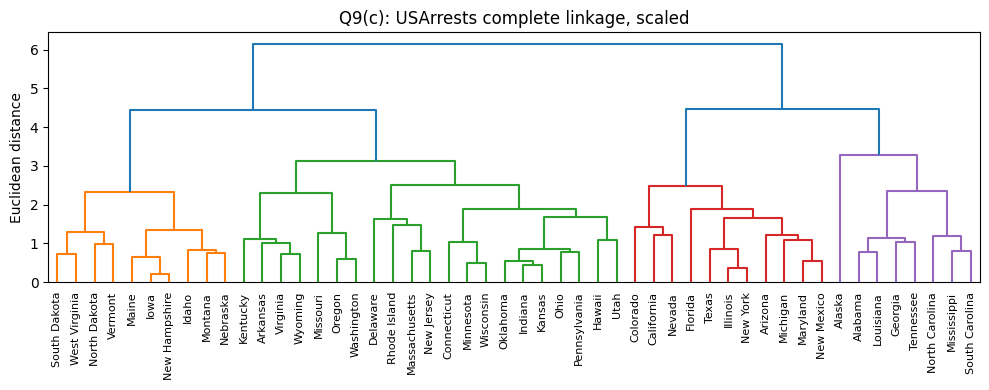

In [4]:
scaled = StandardScaler().fit_transform(usarrests)
Z_scaled = linkage(scaled, method="complete", metric="euclidean")
scaled_clusters = pd.Series(fcluster(Z_scaled, 3, criterion="maxclust"), index=usarrests.index, name="scaled_cluster")
scaled_summary = pd.DataFrame({
    "cluster": scaled_clusters,
    "state": scaled_clusters.index,
}).sort_values(["cluster", "state"])
display(scaled_clusters.value_counts().sort_index().rename("state_count").to_frame())
with pd.option_context("display.max_rows", 60):
    display(scaled_summary)
plt.figure(figsize=(10, 4))
dendrogram(Z_scaled, labels=usarrests.index, leaf_rotation=90)
plt.title("Q9(c): USArrests complete linkage, scaled")
plt.ylabel("Euclidean distance")
plt.tight_layout()

The scaled clustering is the more defensible answer because each variable contributes equally to the distance calculation.  The cluster sizes and state memberships change after scaling, which confirms that the raw solution was sensitive to variable units.

### Q9(d): Should the Variables Be Scaled?

Scaling is appropriate for this exercise because the variables are measured on different numeric scales.  The comparison below shows that scaling is not a cosmetic change; it changes the actual cluster assignment for many states.

In [5]:
membership_compare = pd.concat([raw_clusters, scaled_clusters], axis=1)
membership_compare["changed_after_scaling"] = membership_compare["raw_cluster"] != membership_compare["scaled_cluster"]
display(pd.crosstab(membership_compare["raw_cluster"], membership_compare["scaled_cluster"]))
display(pd.DataFrame({
    "states": [membership_compare.shape[0]],
    "changed_after_scaling": [int(membership_compare["changed_after_scaling"].sum())],
    "percent_changed": [membership_compare["changed_after_scaling"].mean()],
}))

scaled_cluster,1,2,3
raw_cluster,,,
1,1,9,6
2,10,2,2
3,20,0,0


,states,changed_after_scaling,percent_changed
0,50,47,0.94


The variables should be scaled.  In unsupervised learning there is no response variable to absorb a poor distance definition, so the distance metric effectively defines the analysis.  The scaled result is preferable because it prevents the highest-range crime measure from dominating the cluster structure.

## Wine PCA and Clustering

The Wine clustering data set on Kaggle is the classic UCI Wine recognition data set, with 178 wines and 13 chemistry measurements.  This assignment is not a leaderboard task.  The research question is whether the chemistry measurements can be reduced and grouped in a defensible way.  Scaling is required because the variables use different units, and distance-based methods would otherwise be dominated by the largest-scale measurements (Aeberhard & Forina, 1992).

### Wine Setup and Data Quality Checks

Before fitting PCA or clustering models, I check the file shape, missingness, duplicate rows, and basic feature ranges.  These checks matter because unsupervised methods will still form clusters even when the input data have avoidable quality problems.

In [6]:
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

wine = pd.read_csv(KAGGLE / "wine-dataset-for-clustering" / "wine-clustering.csv")
display(wine.isna().sum().rename("missing_count").to_frame())
display(wine.describe().T[["mean", "std", "min", "max"]])
X_scaled = StandardScaler().fit_transform(wine)
display(pd.DataFrame({
    "setup_check": ["rows", "features", "missing_values", "duplicate_rows"],
    "value": [wine.shape[0], wine.shape[1], int(wine.isna().sum().sum()), int(wine.duplicated().sum())],
}))

,missing_count
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


,mean,std,min,max
Alcohol,13.000618,0.811827,11.03,14.83
Malic_Acid,2.336348,1.117146,0.74,5.80
Ash,2.366517,0.274344,1.36,3.23
Ash_Alcanity,19.494944,3.339564,10.60,30.00
Magnesium,99.741573,14.282484,70.00,162.00
Total_Phenols,2.295112,0.625851,0.98,3.88
Flavanoids,2.029270,0.998859,0.34,5.08
Nonflavanoid_Phenols,0.361854,0.124453,0.13,0.66
Proanthocyanins,1.590899,0.572359,0.41,3.58
Color_Intensity,5.058090,2.318286,1.28,13.00


,setup_check,value
0,rows,178
1,features,13
2,missing_values,0
3,duplicate_rows,0


The Wine file is clean enough for PCA and clustering: it has 178 rows, 13 numeric features, no missing values, and no duplicate rows.  The feature ranges are still very different, so the data-quality check supports standardization rather than raw-distance clustering.

### Assumption Check 1: Correlation Structure

PCA is most useful when the original variables contain shared structure.  I inspect the correlation matrix before PCA to verify that dimension reduction is solving a real redundancy problem rather than compressing unrelated measurements.

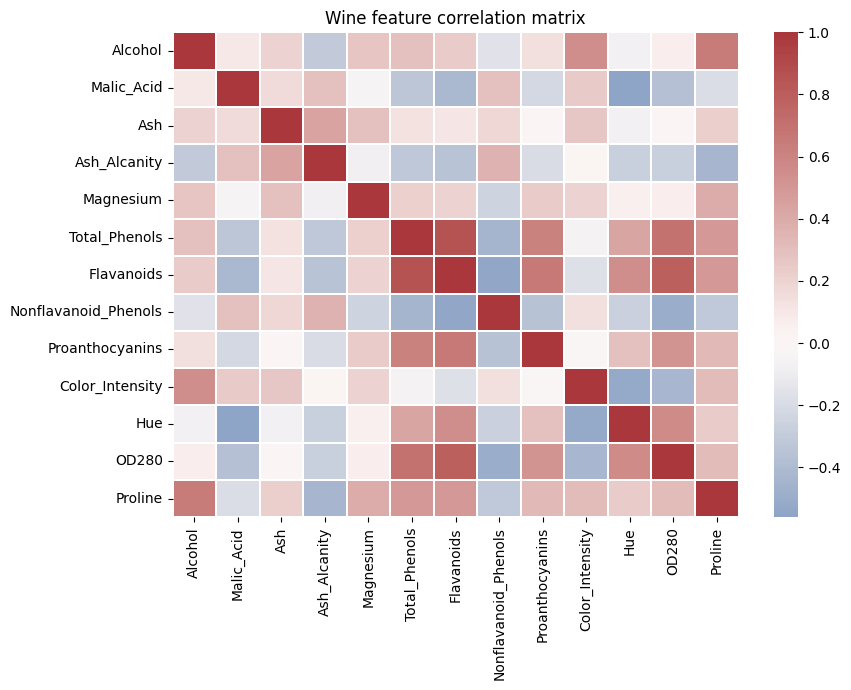

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(wine.corr(), cmap="vlag", center=0, linewidths=.3)
plt.title("Wine feature correlation matrix")
plt.tight_layout()

The correlation matrix shows enough dependence among chemistry measures to justify PCA.  This does not prove that PCA is required, but it gives a practical reason to reduce the feature space before clustering: several variables share information, and clustering directly on all 13 standardized variables would give correlated measures repeated influence.

### PCA: Retaining at Least 80% of Variance

PCA reduces the correlated chemistry measurements before clustering.  I retain the smallest number of components that explain at least 80% of the total standardized variance, then inspect the loadings so the components can still be tied back to the original measurements.

In [8]:
pca_full = PCA().fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumulative >= .80) + 1)
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
scores = pca.fit_transform(X_scaled)
print("Components needed for 80% variance:", n_components)
print("Cumulative variance retained:", round(float(cumulative[n_components - 1]), 4))
display(pd.DataFrame({"component": range(1, len(cumulative)+1), "cumulative_variance": cumulative}).head(10))
loadings = pd.DataFrame(
    pca.components_.T,
    index=wine.columns,
    columns=[f"PC{i}" for i in range(1, n_components + 1)],
)
display(loadings.iloc[:, :min(4, n_components)])

Components needed for 80% variance: 5
Cumulative variance retained: 0.8016


,component,cumulative_variance
0,1,0.361988
1,2,0.554063
2,3,0.665300
3,4,0.735990
4,5,0.801623
5,6,0.850981
6,7,0.893368
7,8,0.920175
8,9,0.942397
9,10,0.961697


,PC1,PC2,PC3,PC4
Alcohol,0.144329,0.483652,-0.207383,-0.017856
Malic_Acid,-0.245188,0.224931,0.089013,0.536890
Ash,-0.002051,0.316069,0.626224,-0.214176
Ash_Alcanity,-0.239320,-0.010591,0.612080,0.060859
Magnesium,0.141992,0.299634,0.130757,-0.351797
Total_Phenols,0.394661,0.065040,0.146179,0.198068
Flavanoids,0.422934,-0.003360,0.150682,0.152295
Nonflavanoid_Phenols,-0.298533,0.028779,0.170368,-0.203301
Proanthocyanins,0.313429,0.039302,0.149454,0.399057
Color_Intensity,-0.088617,0.529996,-0.137306,0.065926


PCA retains 5 components and preserves 80.2% of the standardized variance.  That satisfies the assignment requirement while reducing the clustering space from 13 variables to 5 components.  The loadings table matters because principal components are mathematical summaries; without loadings, the analysis would not explain which chemistry measures define the lower-dimensional space (Jolliffe, 2002).

### K-Means: Comparing Candidate Values of k

K-means is evaluated across several cluster counts rather than fixed at one value.  Inertia shows compactness, while silhouette score adds a separation check, so the selected k is based on more than visual preference.

,k,inertia,silhouette
0,2,1201.157500,0.323917
1,3,825.020838,0.369076
2,4,723.935749,0.325619
3,5,661.429070,0.307802
4,6,605.376056,0.272779
5,7,558.113912,0.275598


Selected k by silhouette: 3


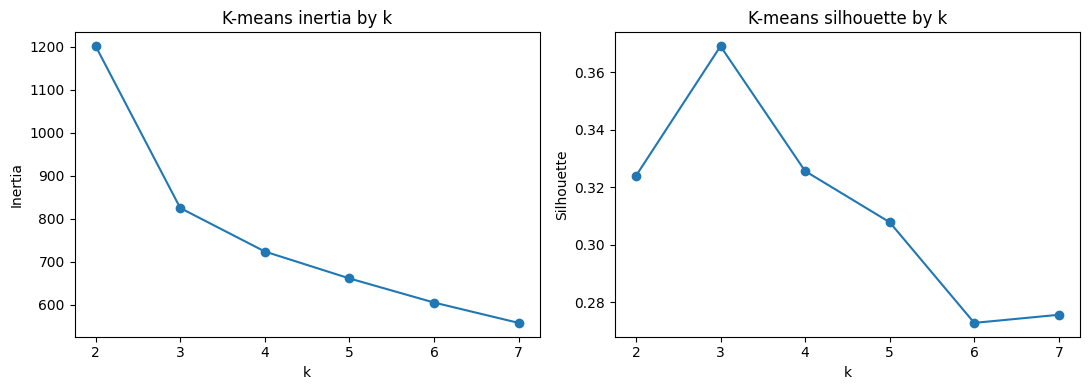

In [9]:
rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(scores)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(scores, km.labels_)})
cluster_eval = pd.DataFrame(rows)
display(cluster_eval)
best_k = int(cluster_eval.sort_values("silhouette", ascending=False).iloc[0]["k"])
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20).fit(scores)
print("Selected k by silhouette:", best_k)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cluster_eval["k"], cluster_eval["inertia"], marker="o")
axes[0].set_title("K-means inertia by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(cluster_eval["k"], cluster_eval["silhouette"], marker="o")
axes[1].set_title("K-means silhouette by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()

The best silhouette score occurs at k=3, so I use three clusters for the remaining k-means interpretation.  The inertia curve keeps falling as k increases, which is expected, but the silhouette score gives a clearer separation criterion and points to the same substantive structure as the known three-cultivar source data.

### K-Means Cluster Profiles

The selected clusters need to be translated back into original chemistry units.  The profile table below reports the mean chemistry values by k-means cluster, so the output is interpretable rather than only a set of labels in PCA space.

In [10]:
wine_profiles = wine.assign(kmeans_cluster=km_best.labels_).groupby("kmeans_cluster").mean()
cluster_sizes = pd.Series(km_best.labels_, name="kmeans_cluster").value_counts().sort_index().rename("count").to_frame()
display(cluster_sizes)
display(wine_profiles)

,count
kmeans_cluster,
0,65
1,51
2,62


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
kmeans_cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


The profile table shows that the clusters are chemically different, not just computationally separated.  This is important because k-means always assigns observations to clusters, but meaningful clusters should also have interpretable feature profiles.

### K-Means Visualization on the First Two Principal Components

The first two PCA scores provide a readable visual summary of the selected k-means result.  The plot does not use all five retained components, so it is a diagnostic view rather than the full model space.

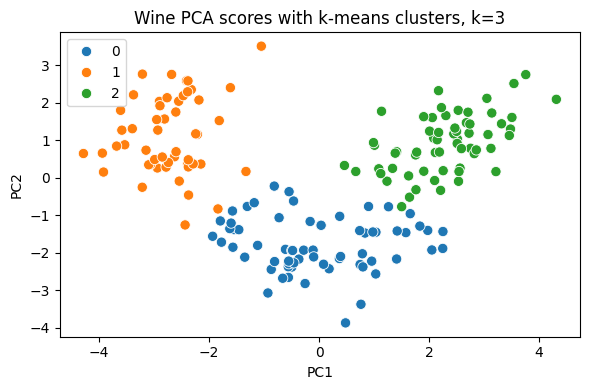

In [11]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=km_best.labels_, palette="tab10", s=55)
plt.title(f"Wine PCA scores with k-means clusters, k={best_k}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

The PC1/PC2 plot shows visible separation among the three selected clusters, although the display is only two-dimensional.  The plot supports the k=3 decision, while the profile table remains the stronger interpretation because the actual clustering used five retained components.

### Hierarchical Clustering: Method Comparison

Hierarchical clustering gives a second view of the same standardized PCA scores.  I use Ward linkage as the primary comparison because it is also variance-oriented, and I add complete linkage as a sensitivity check because it defines inter-cluster distance differently (Ward, 1963).

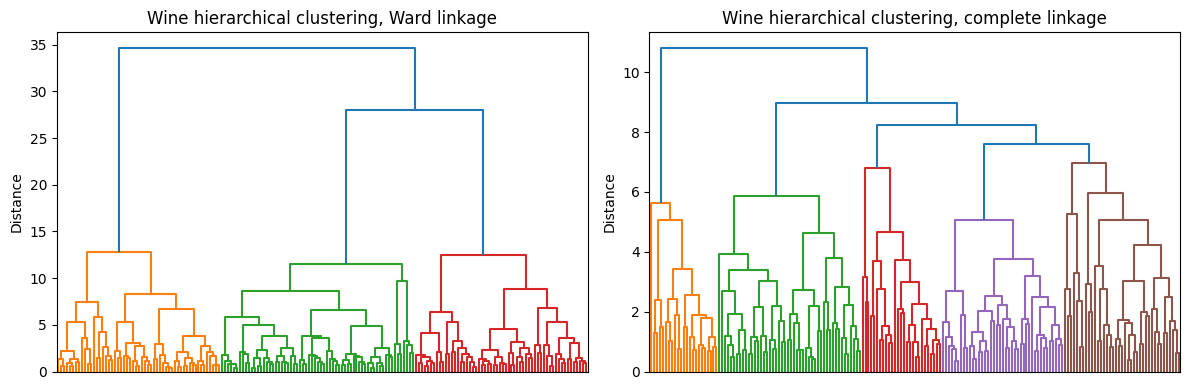

In [12]:
Z_wine_ward = linkage(scores, method="ward")
Z_wine_complete = linkage(scores, method="complete", metric="euclidean")
ward_labels = fcluster(Z_wine_ward, best_k, criterion="maxclust") - 1
complete_labels = fcluster(Z_wine_complete, best_k, criterion="maxclust") - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dendrogram(Z_wine_ward, no_labels=True, ax=axes[0])
axes[0].set_title("Wine hierarchical clustering, Ward linkage")
axes[0].set_ylabel("Distance")
dendrogram(Z_wine_complete, no_labels=True, ax=axes[1])
axes[1].set_title("Wine hierarchical clustering, complete linkage")
axes[1].set_ylabel("Distance")
plt.tight_layout()

The dendrograms show that the three-cluster structure is more stable under Ward linkage than under complete linkage.  This is useful because the hierarchical result is not only a second algorithm, but also a check on how sensitive the grouping is to the definition of cluster distance.

### Hierarchical Clustering Agreement With K-Means

Cluster labels are arbitrary, so I compare methods by matching labels to maximize agreement and by reporting adjusted Rand index.  This avoids treating label 0 from one method as automatically equivalent to label 0 from another method.

In [13]:
def cluster_agreement(reference_labels, comparison_labels, comparison_name):
    table = pd.crosstab(
        pd.Series(reference_labels, name="kmeans"),
        pd.Series(comparison_labels, name=comparison_name),
    )
    row_ind, col_ind = linear_sum_assignment(-table.to_numpy())
    matched = int(table.to_numpy()[row_ind, col_ind].sum())
    return table, {
        "comparison": comparison_name,
        "matched_count": matched,
        "total": int(table.to_numpy().sum()),
        "matched_rate": matched / int(table.to_numpy().sum()),
        "adjusted_rand_index": adjusted_rand_score(reference_labels, comparison_labels),
    }

ward_table, ward_agreement = cluster_agreement(km_best.labels_, ward_labels, "ward")
complete_table, complete_agreement = cluster_agreement(km_best.labels_, complete_labels, "complete")
display(ward_table)
display(complete_table)
display(pd.DataFrame([ward_agreement, complete_agreement]))

ward,0,1,2
kmeans,,,
0,6,3,56
1,49,0,2
2,0,62,0


complete,0,1,2
kmeans,,,
0,21,0,44
1,2,48,1
2,0,0,62


,comparison,matched_count,total,matched_rate,adjusted_rand_index
0,ward,167,178,0.938202,0.826576
1,complete,131,178,0.735955,0.480868


Ward hierarchical clustering agrees with k-means on 167 of 178 observations after optimal label matching, or 93.8%.  Complete linkage agrees on 131 of 178 observations, or 73.6%.  The stronger Ward agreement supports the three-cluster finding, while the complete-linkage difference is a reminder that unsupervised results are partly method-dependent.

### Assumption and Stability Diagnostics

The main assumptions here are practical: clean numeric input, comparable feature scales, a useful lower-dimensional representation, meaningful Euclidean distance, and stable cluster structure.  I check cluster-level silhouette values and seed stability to make those assumptions visible.

In [14]:
silhouette_detail = pd.DataFrame({
    "cluster": km_best.labels_,
    "silhouette": silhouette_samples(scores, km_best.labels_),
})
display(
    silhouette_detail.groupby("cluster")["silhouette"]
    .agg(count="count", mean="mean", minimum="min")
    .reset_index()
)
stability_rows = []
for seed in [1, 7, 21, 42, 99]:
    seeded = KMeans(n_clusters=best_k, random_state=seed, n_init=20).fit(scores)
    stability_rows.append({
        "seed": seed,
        "ari_vs_primary": adjusted_rand_score(km_best.labels_, seeded.labels_),
        "inertia": seeded.inertia_,
        "silhouette": silhouette_score(scores, seeded.labels_),
    })
display(pd.DataFrame(stability_rows))

,cluster,count,mean,minimum
0,0,65,0.246133,-0.050862
1,1,51,0.460550,0.090541
2,2,62,0.422725,0.045439


,seed,ari_vs_primary,inertia,silhouette
0,1,1.000000,825.020838,0.369076
1,7,1.000000,825.020838,0.369076
2,21,1.000000,825.020838,0.369076
3,42,1.000000,825.020838,0.369076
4,99,0.981998,825.182438,0.367729


The silhouette diagnostics show that all three clusters have positive average silhouettes, although one cluster is less cleanly separated than the others.  The seed-stability check is strong: four of five seeds reproduce the primary k-means labels exactly by adjusted Rand index, and the fifth is still very close.  This supports the k=3 solution as stable for this preprocessing choice, but the complete-linkage sensitivity still argues for interpreting the clusters as exploratory structure rather than confirmed classes (Ezugwu et al., 2022).

In [15]:
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 7/Assignment 7/MaldonadoJDDS8555-7.ipynb",
    ],
}))

,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 7/Assignment 7/MaldonadoJDDS8555-7.ipynb


## Interpretation

The main finding is that the Wine chemistry data support a stable three-cluster structure after standardization and PCA.  PCA retained 5 components and 80.2% of the variance, reducing redundancy while preserving most of the chemical information (Jolliffe, 2002).  K-means selected k=3 by silhouette, and the cluster profiles showed meaningful differences in original chemistry measures.  Ward hierarchical clustering agreed with k-means on 167 of 178 wines after label matching, which makes the three-cluster result more credible than a single-method solution.  The assumption checks show no missing or duplicate input rows, support scaling, show correlated predictors that justify PCA, and document both silhouette separation and seed stability.  The limitation is that these are unsupervised groups.  They should be interpreted as exploratory wine-chemistry clusters, not as proven cultivar labels, even though the source data are known to come from three cultivars (Aeberhard & Forina, 1992; Ezugwu et al., 2022).

## References

Aeberhard, S., & Forina, M. (1992). *Wine* [Dataset].  UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J

Ezugwu, A.  E., Ikotun, A.  M., Oyelade, O.  O., Abualigah, L., Agushaka, J.  O., Eke, C.  I., & Akinyelu, A.  A. (2022).  A comprehensive survey of clustering algorithms: State-of-the-art machine learning applications, taxonomy, challenges, and future research prospects. *Engineering Applications of Artificial Intelligence, 110*, 104743. https://doi.org/10.1016/j.engappai.2022.104743

Jolliffe, I.  T. (2002). *Principal component analysis* (2nd ed.).  Springer. https://doi.org/10.1007/b98835

MacQueen, J. (1967).  Some methods for classification and analysis of multivariate observations.  In *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability* (Vol.  1, pp.  281-297).

Ward, J.  H. (1963).  Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association, 58*(301), 236-244. https://doi.org/10.1080/01621459.1963.10500845